# Этап 1: сравнение моделей семантического поиска

В этом ноутбуке выполняется сравнение embedding-моделей для задачи семантического поиска по корпусу функций.  
Цель работы — по текстовому запросу найти наиболее подходящие функции и сравнить качество моделей с помощью метрик `Precision@3` и `MRR`.

In [1]:
from pathlib import Path
import json

DATA_DIR = Path("dataset")

print(DATA_DIR.exists())

True


## Этап 2. Изучение датасета

На этом этапе загружаются JSON-файлы с корпусом функций, тестовыми вопросами и категориями.  
Также проверяется количество объектов, структура данных, языки функций и распределение по категориям.

In [2]:
with open("dataset/code_corpus.json", encoding="utf-8") as f:
    corpus = json.load(f)

In [3]:
with open("dataset/eval_questions.json", encoding="utf-8") as f:
    questions = json.load(f)


In [4]:
with open("dataset/categories.json", encoding="utf-8") as f:
    categories = json.load(f)["categories"]

In [5]:
print(len(corpus))      
print(len(questions))   
print(len(categories))

200
25
5


In [6]:
corpus[0]

{'id': 'func_001',
 'language': 'python',
 'function_name': 'verify_jwt_token',
 'category': 'auth',
 'description': 'Проверяет JWT-токен и возвращает payload или причину невалидности.',
 'code': 'def verify_jwt_token(token: str, secret: str) -> dict:\n    """Проверяет JWT-токен и возвращает payload или причину невалидности."""\n    try:\n        payload = jwt.decode(token, secret, algorithms=["HS256"])\n        return {"valid": True, "data": payload}\n    except jwt.ExpiredSignatureError:\n        return {"valid": False, "error": "expired"}\n    except jwt.InvalidTokenError:\n        return {"valid": False, "error": "invalid"}'}

In [7]:
print(corpus[0].keys())
print(questions[0].keys())

dict_keys(['id', 'language', 'function_name', 'category', 'description', 'code'])
dict_keys(['question_id', 'query', 'language', 'correct_chunk_id'])


In [8]:
languages = []

for item in corpus:
    languages.append(item["language"])

set(languages)

{'java', 'python'}

In [9]:
from collections import Counter

Counter(languages)

Counter({'python': 100, 'java': 100})

In [10]:
category_names = []

for item in corpus:
    category_names.append(item["category"])

set(category_names)

{'auth', 'database', 'http', 'utils', 'validation'}

In [11]:
Counter(category_names)

Counter({'auth': 40,
         'database': 40,
         'http': 40,
         'validation': 40,
         'utils': 40})

In [12]:
question_languages = []

for question in questions:
    question_languages.append(question["language"])

Counter(question_languages)

Counter({'ru': 15, 'en': 10})

In [13]:
questions[0]

{'question_id': 'q_01',
 'query': 'как проверить, истёк ли токен?',
 'language': 'ru',
 'correct_chunk_id': 'func_001'}

In [14]:
import pandas as pd

corpus_df = pd.DataFrame(corpus)
questions_df = pd.DataFrame(questions)

In [15]:
corpus_df.head()

,id,language,function_name,category,description,code
0,func_001,python,verify_jwt_token,auth,Проверяет JWT-токен и возвращает payload или п...,"def verify_jwt_token(token: str, secret: str) ..."
1,func_002,python,hash_password,auth,Хэширует пароль с помощью bcrypt с cost-фактор...,def hash_password(password: str) -> str:\n ...
2,func_003,python,check_password,auth,Сравнивает открытый пароль с bcrypt-хэшем и во...,"def check_password(plain: str, hashed: str) ->..."
3,func_004,python,generate_session_id,auth,Генерирует уникальный идентификатор сессии на ...,"def generate_session_id() -> str:\n """"""Гене..."
4,func_005,python,validate_credentials,auth,"Проверяет, что логин и пароль непустые и соотв...","def validate_credentials(username: str, passwo..."


In [16]:
questions_df.head()

,question_id,query,language,correct_chunk_id
0,q_01,"как проверить, истёк ли токен?",ru,func_001
1,q_02,where is password hashing implemented,en,func_002
2,q_03,проверка двухфакторной аутентификации по коду,ru,func_014
3,q_04,logout user and clear session,en,func_010
4,q_05,проверить права администратора на эндпоинте,ru,func_109


In [17]:
corpus_df["language"].value_counts()

language
python    100
java      100
Name: count, dtype: int64

In [18]:
corpus_df["category"].value_counts()

category
auth          40
database      40
http          40
validation    40
utils         40
Name: count, dtype: int64

In [19]:
questions_df["language"].value_counts()

language
ru    15
en    10
Name: count, dtype: int64

### Вывод по датасету

В датасете 200 фрагментов кода и 25 тестовых вопросов. Корпус содержит два языка программирования: Python и Java, по 100 функций каждого языка. Все функции распределены по пяти категориям: auth, database, http, validation и utils, по 40 функций в каждой категории. Вопросы представлены на двух языках: 15 русских и 10 английских.

## Этап 3. Подготовка данных

На этом этапе для каждой функции формируется единый текст, который будет передаваться embedding-модели.  
В текст объединяются имя функции, описание и исходный код.

Такой подход выбран потому, что поисковые запросы написаны обычным языком, а описание функции помогает модели лучше связать запрос со смыслом кода.

In [20]:
# Формируем единый текст функции для передачи в embedding-модель.
# Используем имя функции, описание и код, чтобы модель видела больше смысла.
def build_function_text(row):
    return (
        f"Имя функции: {row['function_name']} "
        f"Описание: {row['description']} "
        f"Код:\n{row['code']}"
    )

In [21]:
corpus_df["text_for_embedding"] = corpus_df.apply(build_function_text, axis=1)

In [22]:
corpus_df[["id", "function_name", "text_for_embedding"]].head()

,id,function_name,text_for_embedding
0,func_001,verify_jwt_token,Имя функции: verify_jwt_token Описание: Провер...
1,func_002,hash_password,Имя функции: hash_password Описание: Хэширует ...
2,func_003,check_password,Имя функции: check_password Описание: Сравнива...
3,func_004,generate_session_id,Имя функции: generate_session_id Описание: Ген...
4,func_005,validate_credentials,Имя функции: validate_credentials Описание: Пр...


In [23]:
# Применяем функцию подготовки текста ко всем функциям корпуса.
# В результате получаем список текстов, которые будут кодироваться моделью.
corpus_texts = corpus_df["text_for_embedding"].tolist()
corpus_ids = corpus_df["id"].tolist()

In [24]:
print(len(corpus_texts))
print(len(corpus_ids))
print(corpus_ids[:5])

200
200
['func_001', 'func_002', 'func_003', 'func_004', 'func_005']


In [25]:
# Подготавливаем запросы и правильные ответы.
# query_texts — тексты вопросов,
# correct_ids — ID правильных функций,
query_texts = questions_df["query"].tolist()
correct_ids = questions_df["correct_chunk_id"].tolist()

In [26]:
print(len(query_texts))
print(len(correct_ids))
print(query_texts[:3])
print(correct_ids[:3])

25
25
['как проверить, истёк ли токен?', 'where is password hashing implemented', 'проверка двухфакторной аутентификации по коду']
['func_001', 'func_002', 'func_014']


In [27]:
from sentence_transformers import SentenceTransformer
# Задаём две embedding-модели, которые будем сравнивать.
# Обе модели будут работать с одним и тем же корпусом и одними и теми же запросами.
model_names = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
]

## Этап 4. Работа с моделями

На этом этапе загружаются две embedding-модели.  
Для каждой модели отдельно рассчитываются эмбеддинги функций и эмбеддинги поисковых запросов.

Эмбеддинг — это числовое представление текста, по которому можно сравнивать объекты по смысловой близости.

In [28]:
# Загружаем модели SentenceTransformer.
# Сохраняем их в словарь, чтобы потом обращаться к модели по её названию.

models = {}

for name in model_names:
    print("Загружаю модель:", name)
    models[name] = SentenceTransformer(name)

Загружаю модель: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Загружаю модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [29]:
print(models.keys())

dict_keys(['sentence-transformers/all-MiniLM-L6-v2', 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'])


In [30]:
# Для каждой модели считаем эмбеддинги функций и запросов.
# Эмбеддинги сохраняются в словарь, чтобы не пересчитывать их повторно.
embeddings = {}

for name, model in models.items():
    print("Считаю эмбеддинги для модели:", name)

    function_embeddings = model.encode(
        corpus_texts,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    query_embeddings = model.encode(
        query_texts,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    embeddings[name] = {
        "functions": function_embeddings,
        "queries": query_embeddings
    }

Считаю эмбеддинги для модели: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Считаю эмбеддинги для модели: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
# Проверяем размерность эмбеддингов.
# Первая размерность — количество объектов, вторая — размер вектора модели
for name in model_names:
    print(name)
    print("Функции:", embeddings[name]["functions"].shape)
    print("Запросы:", embeddings[name]["queries"].shape)
    print()

sentence-transformers/all-MiniLM-L6-v2
Функции: (200, 384)
Запросы: (25, 384)

sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Функции: (200, 384)
Запросы: (25, 384)



In [32]:
assert embeddings["sentence-transformers/all-MiniLM-L6-v2"]["functions"].shape == (200, 384)
assert embeddings["sentence-transformers/all-MiniLM-L6-v2"]["queries"].shape == (25, 384)

assert embeddings["sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"]["functions"].shape == (200, 384)
assert embeddings["sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"]["queries"].shape == (25, 384)

print("4 этап выполнен успешно")

4 этап выполнен успешно


## Этап 5. Семантический поиск

На этом этапе рассчитывается косинусное сходство между эмбеддингами запросов и эмбеддингами функций.  
Для каждого запроса выбираются три функции с наибольшим значением сходства.

Именно эти три функции образуют результат поиска `top-3`.

In [33]:
# Импортируем функцию для расчёта косинусного сходства.
# Она покажет, насколько каждый запрос похож на каждую функцию.
from sklearn.metrics.pairwise import cosine_similarity

In [34]:
# Функция выбирает top-3 функции для каждого запроса.
# На вход она получает матрицу сходства и список ID функций.
def get_top3_ids(similarities, corpus_ids):
    top3_ids = []

    for row in similarities:
        top3_indexes = row.argsort()[::-1][:3]
        current_top3 = [corpus_ids[i] for i in top3_indexes]
        top3_ids.append(current_top3)

    return top3_ids

In [35]:
# Для каждой модели считаем сходство между запросами и функциями.
# Затем сохраняем top-3 найденных функции для каждого запроса.
top3_by_model = {}

for model_name in model_names:
    function_embeddings = embeddings[model_name]["functions"]
    query_embeddings = embeddings[model_name]["queries"]

    similarities = cosine_similarity(query_embeddings, function_embeddings)

    top3_by_model[model_name] = get_top3_ids(similarities, corpus_ids)

## Этап 6. Оценка моделей

На этом этапе рассчитываются метрики качества для каждой модели.

`Precision@3` показывает, попал ли правильный ответ в первые три результата поиска.  
`MRR` дополнительно учитывает позицию правильного ответа: чем выше он находится в выдаче, тем лучше результат.

После расчёта метрик результаты моделей сравниваются в общей таблице.

In [36]:
# Precision@3 показывает, попал ли правильный ответ в первые три результата.
# Если правильная функция есть в top-3, ставим 1, иначе 0.
def precision_at_3(top3_ids, correct_ids):
    scores = []

    for predicted, correct in zip(top3_ids, correct_ids):
        if correct in predicted:
            scores.append(1)
        else:
            scores.append(0)

    return sum(scores) / len(scores)

# MRR учитывает позицию правильного ответа в выдаче.
# Если ответ на 1 месте — вклад 1, на 2 месте — 1/2, на 3 месте — 1/3.

def mrr(top3_ids, correct_ids):
    scores = []

    for predicted, correct in zip(top3_ids, correct_ids):
        if correct in predicted:
            rank = predicted.index(correct) + 1
            scores.append(1 / rank)
        else:
            scores.append(0)

    return sum(scores) / len(scores)

In [37]:
correct_ids = questions_df["correct_chunk_id"].tolist()

correct_ids[:5]

['func_001', 'func_002', 'func_014', 'func_010', 'func_109']

In [38]:
corpus_ids = corpus_df["id"].tolist()
corpus_ids[:5]

['func_001', 'func_002', 'func_003', 'func_004', 'func_005']

In [39]:
model_1 = model_names[0]
model_2 = model_names[1]

analysis_df = pd.DataFrame({
    "query": query_texts,
    "correct_id": correct_ids,
    "language": question_languages,
    "top3_model_1": top3_by_model[model_1],
    "top3_model_2": top3_by_model[model_2],
})

In [40]:
# Считаем метрики для каждой модели и собираем результаты в таблицу.
# Для честного сравнения используются одинаковые запросы и одинаковый корпус.

results = []

for model_name in model_names:
    function_embeddings = embeddings[model_name]["functions"]
    query_embeddings = embeddings[model_name]["queries"]

    similarities = cosine_similarity(query_embeddings, function_embeddings)

    top3_real_ids = get_top3_ids(similarities, corpus_ids)

    precision = precision_at_3(top3_real_ids, correct_ids)
    mrr_score = mrr(top3_real_ids, correct_ids)

    results.append({
        "model": model_name,
        "Precision@3": precision,
        "MRR": mrr_score
    })

results_df = pd.DataFrame(results)
results_df

,model,Precision@3,MRR
0,sentence-transformers/all-MiniLM-L6-v2,0.48,0.366667
1,sentence-transformers/paraphrase-multilingual-...,0.84,0.540000


### Этап 7. Дополнительный анализ

Было проведено сравнение качества моделей отдельно для русских и английских запросов.

Первая модель показала качество Precision@3:
- английские запросы: 0.80
- русские запросы: 0.27

Вторая модель показала качество Precision@3:
- английские запросы: 0.90
- русские запросы: 0.80

По результатам видно, что вторая модель работает лучше на обоих языках. Особенно большая разница наблюдается на русских запросах: первая модель часто не находит правильную функцию в топ-3, а вторая модель сохраняет высокое качество.

Ошибки моделей связаны с тем, что некоторые запросы могут быть короткими, неоднозначными или описывать функцию другими словами, чем она описана в корпусе.

Лучшей моделью выбрана вторая модель, так как она имеет более высокое качество как на русских, так и на английских запросах.


In [41]:
# Создаём таблицу для подробного анализа результатов.
# В ней будут запросы, правильные ответы и top-3 выдача каждой модели.

analysis_df["model_1_correct"] = [
    correct in top3
    for correct, top3 in zip(analysis_df["correct_id"], analysis_df["top3_model_1"])
]

analysis_df["model_2_correct"] = [
    correct in top3
    for correct, top3 in zip(analysis_df["correct_id"], analysis_df["top3_model_2"])
]

In [42]:
# Считаем среднее значение True/False отдельно для каждого языка.
# Так получаем долю успешных запросов для русских и английских вопросов.
language_results = analysis_df.groupby("language")[["model_1_correct", "model_2_correct"]].mean()

language_results

,model_1_correct,model_2_correct
language,,
en,0.800000,0.9
ru,0.266667,0.8


## Этап 8. Визуализация

Для визуализации эмбеддингов была выбрана лучшая модель по результатам оценки качества: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

Эмбеддинги функций имели размерность 384, поэтому для отображения на плоскости была использована t-SNE-проекция в 2 измерения.

На графике каждая точка соответствует одной функции из корпуса, а цвет точки показывает категорию функции. График был сохранён в файл `tsne_best_model.png`.

По визуализации видно, что некоторые категории частично группируются, однако качество модели следует оценивать в первую очередь по метрикам Precision@3 и MRR, а не только по виду t-SNE-графика.

In [43]:
# Берём эмбеддинги функций у лучшей модели.
# Именно их будем использовать для построения t-SNE-графика.
best_model_name = results_df.sort_values("Precision@3", ascending=False).iloc[0]["model"]

best_model_name

'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

In [44]:
# Берём эмбеддинги функций у лучшей модели
best_function_embeddings = embeddings[best_model_name]["functions"]

best_function_embeddings.shape

(200, 384)

In [45]:
from sklearn.manifold import TSNE
# Создаём объект t-SNE для уменьшения размерности эмбеддингов до 2 координат
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)

In [46]:
# Преобразуем эмбеддинги функций в двумерные координаты
tsne_coords = tsne.fit_transform(best_function_embeddings)

tsne_coords.shape

(200, 2)

In [47]:
# Добавляем координаты t-SNE в таблицу с функциями
corpus_df["tsne_x"] = tsne_coords[:, 0]
corpus_df["tsne_y"] = tsne_coords[:, 1]

corpus_df[["id", "category", "tsne_x", "tsne_y"]].head()

,id,category,tsne_x,tsne_y
0,func_001,auth,-14.262836,5.200490
1,func_002,auth,5.121905,7.218927
2,func_003,auth,4.746388,9.271586
3,func_004,auth,6.193943,-1.465800
4,func_005,auth,5.264419,10.762146


In [48]:
# Создаём словари с названиями и цветами категорий.
# Они нужны для подписи легенды и раскраски точек на графике.

category_labels = {
    item["key"]: item["label"]
    for item in categories
}

category_colors = {
    item["key"]: item["color"]
    for item in categories
}

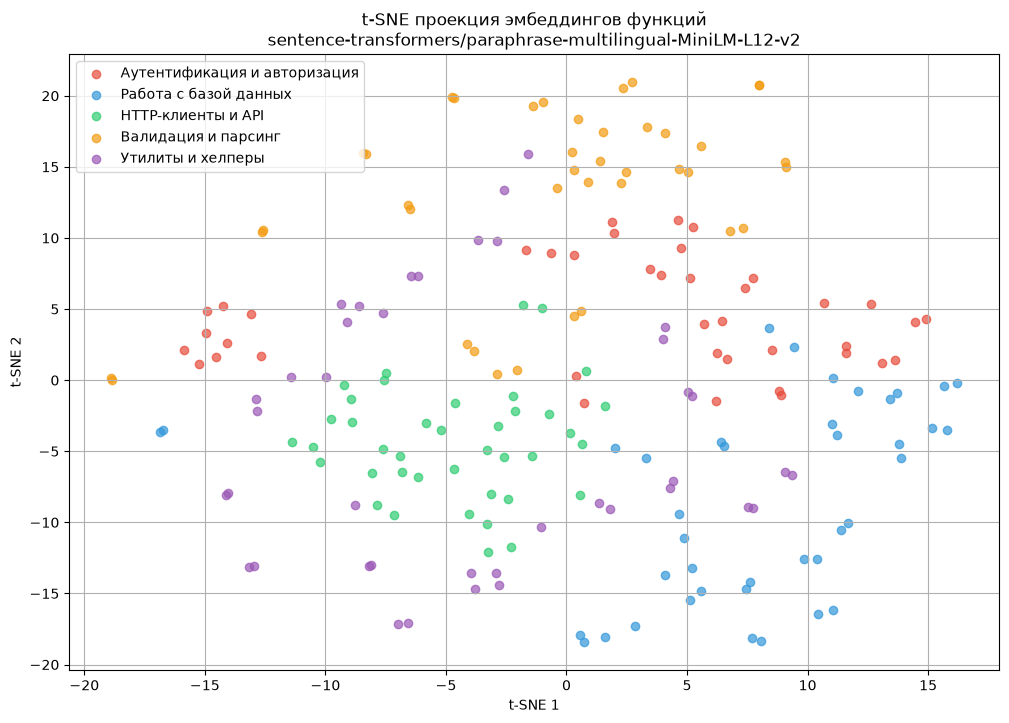

In [49]:
import matplotlib.pyplot as plt
# Строим scatter-график t-SNE.
# Каждая точка — функция, цвет точки — категория функции.
plt.figure(figsize=(12, 8))

for category in corpus_df["category"].unique():
    part = corpus_df[corpus_df["category"] == category]
    
    plt.scatter(
        part["tsne_x"],
        part["tsne_y"],
        label=category_labels[category],
        color=category_colors[category],
        alpha=0.7
    )

plt.title(f"t-SNE проекция эмбеддингов функций\n{best_model_name}")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True)

plt.savefig("tsne_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# Проверяем, что файл с графиком действительно был сохранён.
from pathlib import Path

print("График сохранён:", Path("tsne_best_model.png").exists())

График сохранён: True


## Итоговый вывод

В работе были сравнены две embedding-модели для задачи семантического поиска по корпусу функций. Лучший результат показала модель `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`, так как она получила более высокие значения Precision@3 и MRR. Особенно заметное преимущество эта модель показала на русскоязычных запросах, потому что она является мультиязычной. t-SNE-визуализация показала, что функции частично группируются по тематическим категориям, однако качество модели нужно оценивать прежде всего по метрикам, а не только по виду графика.
